# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**ANSWER:** 17 campaigns that occurred between May 2008 and November 2010

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
(df == '').sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [7]:
df['month'].unique()

array(['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr',
       'sep'], dtype=object)

In [8]:
df['day_of_week'].unique()

array(['mon', 'tue', 'wed', 'thu', 'fri'], dtype=object)

In [9]:
unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']

unknown_counts = pd.DataFrame({
    'Num Unknowns': [(df[col] == 'unknown').sum() for col in unknown_cols],
    'Percentage Unknowns': [(df[col] == 'unknown').mean() * 100 for col in unknown_cols]
}, index=unknown_cols)

print(unknown_counts)

           Num Unknowns  Percentage Unknowns
job                 330             0.801204
marital              80             0.194231
education          1731             4.202680
default            8597            20.872584
housing             990             2.403613
loan                990             2.403613


**ANSWER:** Some columns have an "Unknown" value, which could be interpreted as missing or used as a category.  A few columns would need special handling.
* **month** is an ordinal and should be interpreted as such
* **day_of_week** is also an ordinal and should be interpreted as such
* **duration** should not be included as a feature because its value isn't known until the call has completed and thus cannot be used in a predicitive model.
* **pdays** with values of 999 should be interpreted differently than other values.  We should introduce a new binary column to mark those cases and set any 999 values to 0.
* **y** is the target variable and should be mapped to a 0 or 1

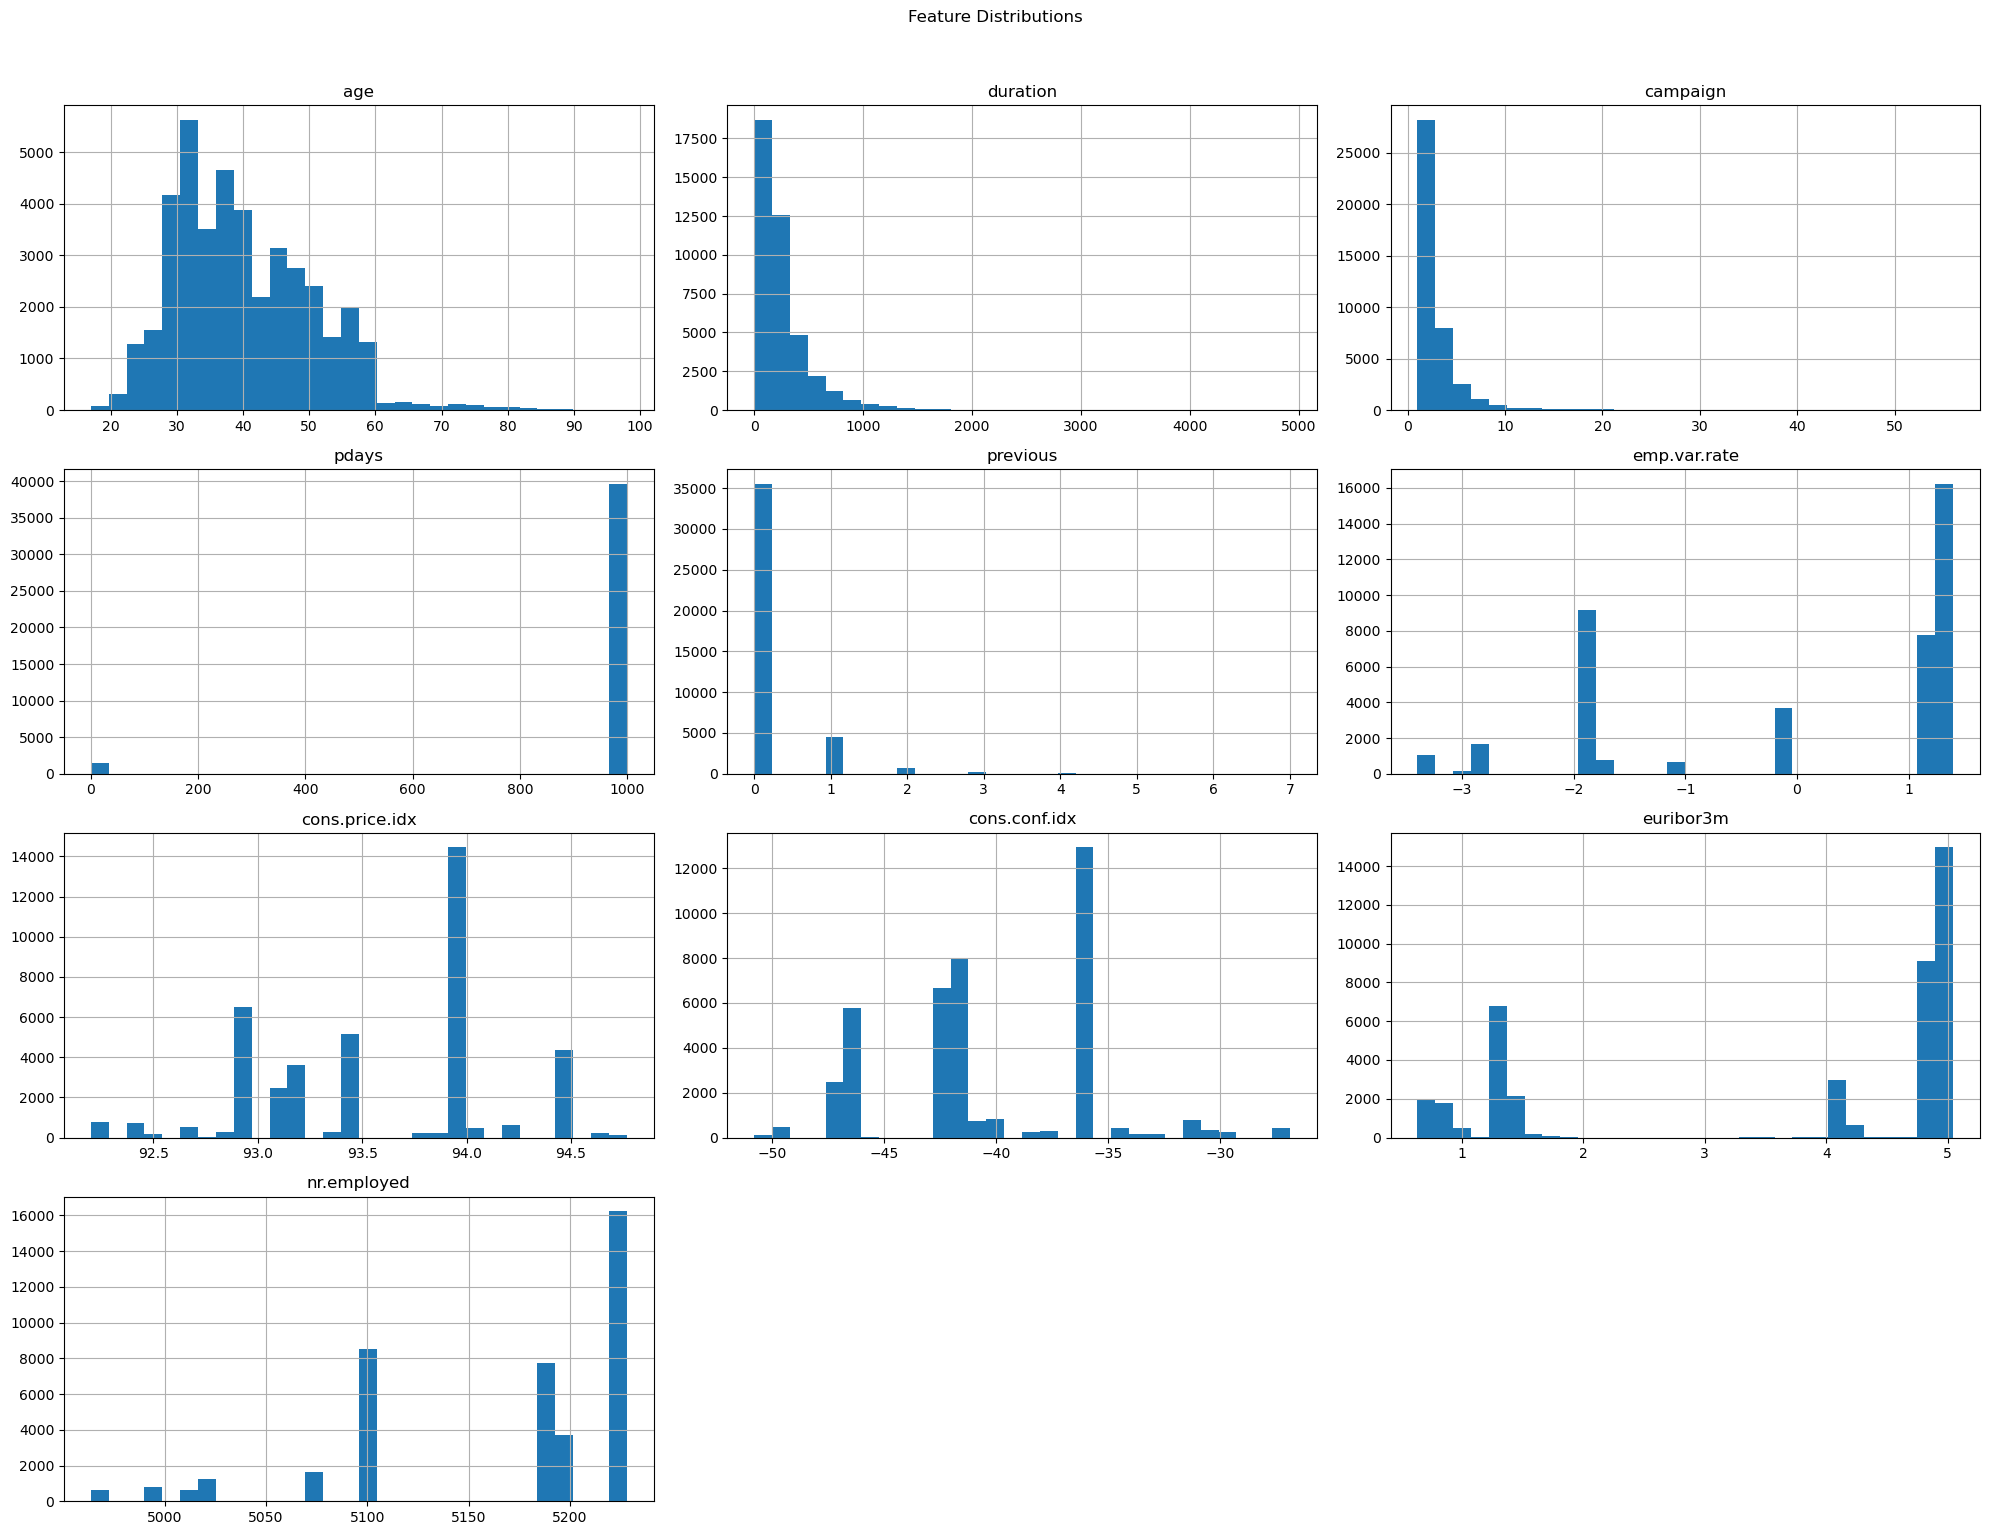

In [10]:
# Plot distributions of numerical data
import matplotlib.pyplot as plt
df.hist(figsize=(20, 15), bins=30)
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

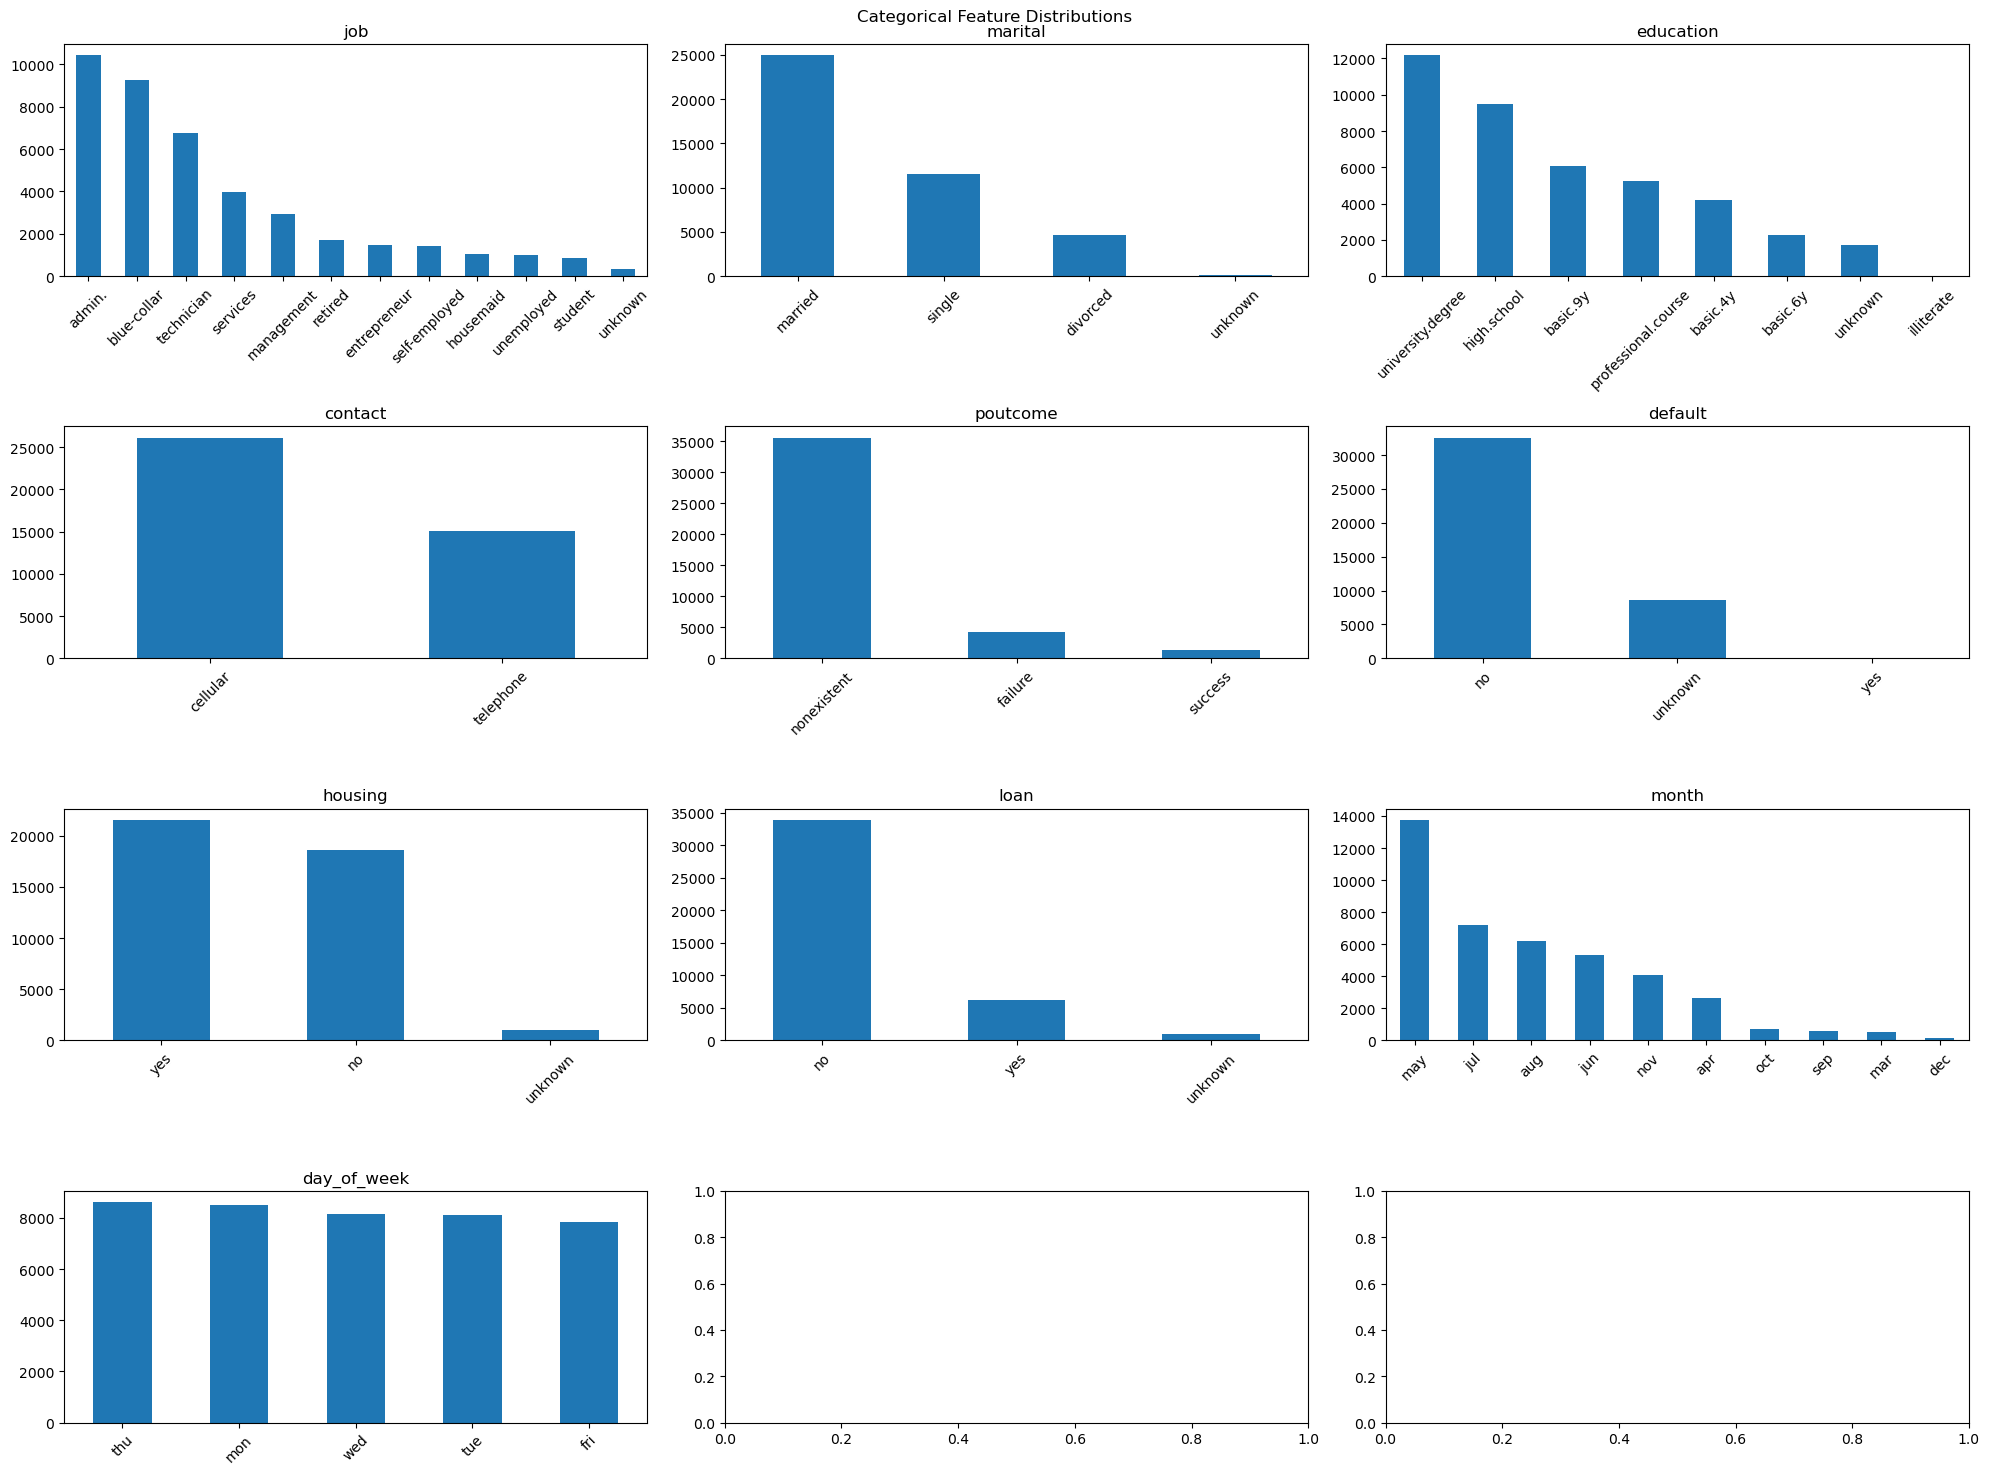

In [11]:
# Plot distributions of categorical data
cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome', 
            'default', 'housing', 'loan', 'month', 'day_of_week']

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Feature Distributions')
plt.tight_layout()
plt.show()

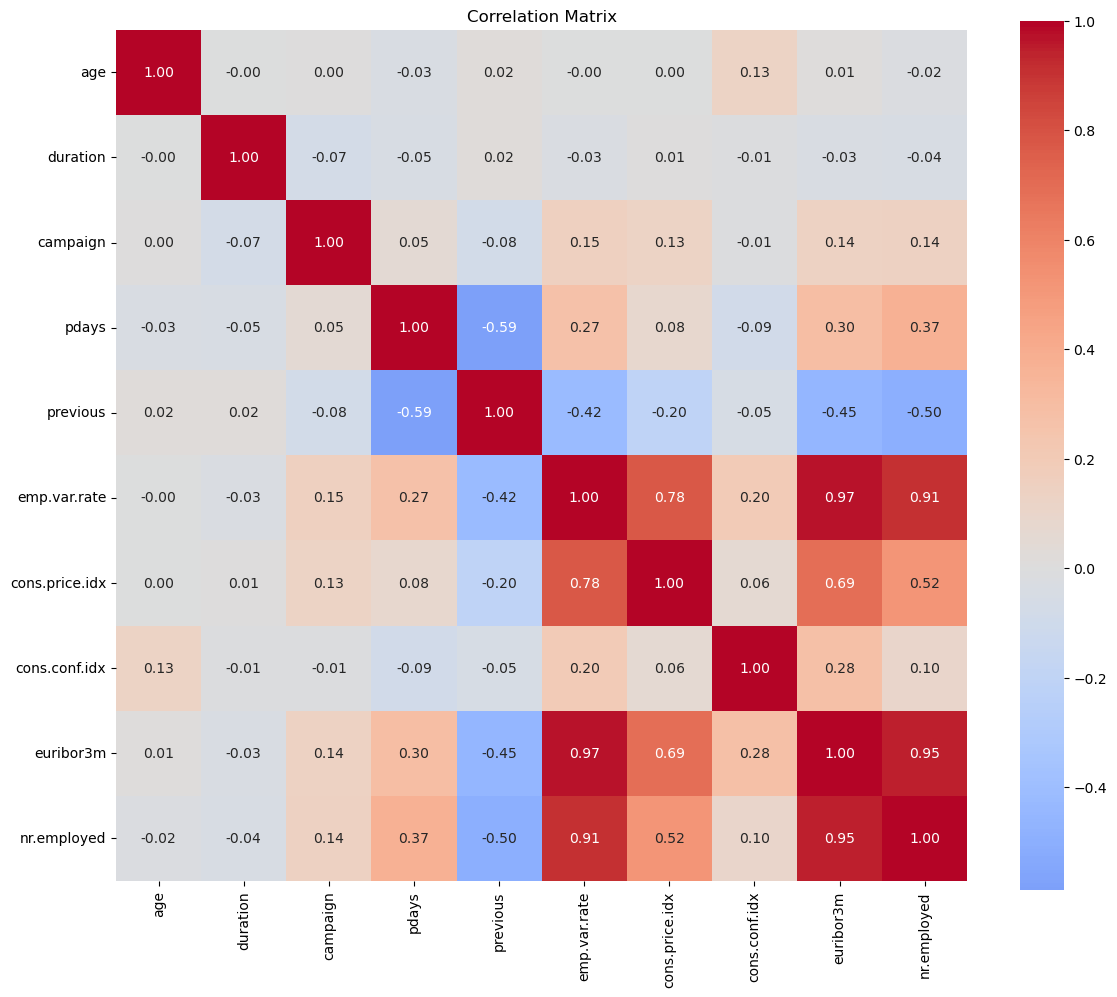

In [12]:
# Plot correlation matrix of numeric data
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**ANSWER:** A bank uses direct marketing via telephone to contact potential customers of a long-term deposit service.  Contacting customers this way is costly in resources.  We are to build a predictive model that can be used to more efficiently target customers that will use the service without wasting resources on customers that are not likely to accept.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [13]:
# drop duration. It isn't a predictive feature because it isn't known ahead of time.
df = df.drop(columns=['duration'])

# drop "other attributes" (per instructions)
df = df.drop(columns=['campaign', 'pdays', 'previous', 'poutcome'])

# drop social and economic context attributes (per instructions)
df = df.drop(columns=['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'])

There are relatively few samples that took place in March, September, October, and December.  This ends up confusing the models into concluding that those months are somehow better for marketing campaigns.  We could drop those rows, but predicting outcome based on leftover months seems arbitrary.  Additionally, January and February weren't represented in our data to begin with.  We want our resulting model to be generalizable to any month.  We will drop `month` completely from our feature set to account for this.

In [14]:
df = df.drop(columns=['month'])

Customers with credit in default is also very under-represented.  The other two possible values are `No` and `Unknown`.  We are dropping `unknown` columns below, which leaves only one valid value.  We will remove the `default` column entirely as it isn't useful.

In [15]:
df = df.drop(columns=['default'])

In [16]:
# Illiterate education is very under-represented. We will drop those rows to avoid confusing our model.
df = df[df['education'] != 'illiterate']

In [17]:
# drop rows with unknown values
unknown_cols = ['job', 'marital', 'education', 'housing', 'loan']
rows_to_drop = df[unknown_cols].isin(['unknown']).any(axis=1)
print(f"Rows with unknowns: {rows_to_drop.sum()}")
df = df[~rows_to_drop]

Rows with unknowns: 2943


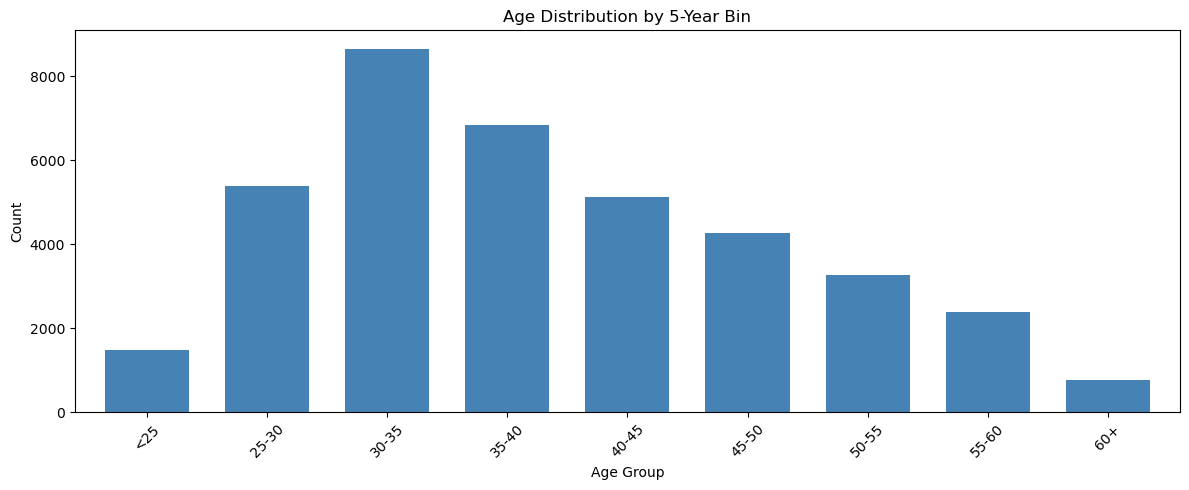

In [18]:
# Bin customers by age and plot the distribution
bins = [0, 25, 30, 35, 40, 45, 50, 55, 60, 100]
labels = ['<25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60+']

df['age_bin'] = pd.cut(df['age'], bins=bins, labels=labels)

df['age_bin'].value_counts().reindex(labels).plot(
    kind='bar',
    figsize=(12, 5),
    color='steelblue',
    width=0.7
)
plt.title('Age Distribution by 5-Year Bin')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The age data has a long upper tail where individual ages become under-represented.  Similarly, ages less than around 22 are under-represented.  To account for this, we will create age bins (as plotted above) and group all ages less than 25 together and ages greater than 60 together.

In [19]:
# Convert age_bin to ordinal
df['age'] = pd.Categorical(df['age_bin'], categories=labels, ordered=True).codes

# Drop age_bin since we no longer need it
df = df.drop(columns=['age_bin'])

In [20]:
# interpret day_of_week as an ordinal
day_order = ['mon','tue','wed','thu','fri']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True).codes

# map y to 0 or 1
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [21]:
print(f"Data rows after trimming: {len(df)}")

Data rows after trimming: 38227


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [22]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['y'])
y = df['y']

# use stratify to ensure that our train and test sets have the same proportion of yes/no rows
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [23]:
y_train.value_counts(normalize=True).max()

0.8887217553382819

**ANSWER:** The baseline model is one that simply returns the majority class.  In this case, 88.9% of calls end in a "no" response, so our baseline model will just always predict "no".  This model isn't actually useful as it doesn't help us predict positive responses, but it establishes a baseline for accuracy.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_cols = ['age', 'day_of_week']

categorical_cols = ['job', 'marital', 'education', 'contact', 'housing', 'loan']

preprocessor = ColumnTransformer([
    ('numerical', StandardScaler(), numerical_cols),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['age', 'day_of_week']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'contact',
                                                   'housing', 'loan'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

### Problem 9: Score the Model

What is the accuracy of your model?

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

y_pred = lr_pipeline.predict(X_test)
accuracy_score(y_test, y_pred)

0.8886999738425321

**ANSWER:** The simple Logistic Regression model has an accuracy of 88.9%.  No improvement from the baseline.  However, accuracy is not the best metric for model comparisons here.  We will switch to ROC-AUC (in Problem 11 below).

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [26]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start
    
    train_accuracy = pipeline.score(X_train, y_train)
    test_accuracy  = pipeline.score(X_test, y_test)
    y_pred = pipeline.predict(X_test)
    
    results.append({
        'Model': name,
        'Train Time': round(train_time, 3),
        'Train Accuracy': round(train_accuracy, 3),
        'Test Accuracy': round(test_accuracy, 3)
    })

pd.DataFrame(results)

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.081,0.889,0.889
1,KNN,0.045,0.892,0.879
2,Decision Tree,0.486,0.915,0.865
3,SVM,56.704,0.889,0.889


Logistic Regression, KNN, and SVM have similar test accuracy.  Decision Tree performs slightly better.  Logistic Regression, KNN, and Decision Tree all train very quickly with none taking longer than a second.  SVM, however, takes much longer to train.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

We'll improve the model in 4 ways:

1. **Evaluation Metric:** Change our evaluation metric to ROC-AUC as it is a better indicator of overall model performance and it works well with imbalanced classes.
2. Adjust our probability threshold from the default of 0.5 to the one that gives the highest F1 score for each model.
3. Use `class_weight='balanced'` on models that support it to account for the imbalanced data set
4. Use Grid Search on each model individually to find the best hyperparameters.  The hyperparameters we will tune are:

**Logistic Regression**
* Regularization strength
* Max iterations

**KNN**
* N neighbors
* Weights (all neighbors get an equal vote or vote effect scales with distance)

**Decision Tree**
* Max tree depth
* Min samples for a split
* Min samples for a leaf
* Criterion

**SVM**
* Regularization strength

In [27]:
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

# Use grid search to tune the given model with the given params to find the best hyperparameters
def tune_hyperparameters(model, param_grid):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1, # uses multiple processors
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    y_pred = grid_search.predict(X_test)
    return parse_params(grid_search.best_params_)

# Parses the hyperparameter names so they can be passed directly into a model
def parse_params(best_params):
    return {k.replace('model__', ''): v for k, v in best_params.items()}

# Fit the model.
def fit_model(model):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    return pipeline

# Calculate the F1 score at each point along the precision_recall_curve and select the point with the highest F1 score.
# This will be a good threshold to use for the model.
def tune_threshold(y_pred_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
    with np.errstate(invalid='ignore'): # Suppress warnings when precision + recall = 0
        f1_scores = 2 * ((precisions * recalls) / (precisions + recalls))
        f1_scores = np.nan_to_num(f1_scores) # Handle invalid data when precision + recall = 0
    return thresholds[np.argmax(f1_scores)]
    
# Add random_state and class_weight if the model supports them
def add_default_params(model, params):
    if 'random_state' in model.get_params():
        params['random_state'] = 42
    if 'class_weight' in model.get_params():
        params['class_weight'] = 'balanced'
    return params

def tune_model(model_name, 
               search_model, # The model to use for hyperparameter tuning (this is due to SVC tuning times)
               param_grid, # The params to search over during hyperparameter tuning
               final_model, # The final model to fit (due to SVC tuning times)
               results): # Dataframe to fill with results
    search_model_params = {}
    add_default_params(search_model, search_model_params)
    
    print(f"Tuning {model_name}...")
    start = time.time()
    final_model_params = tune_hyperparameters(search_model.set_params(**search_model_params), param_grid)
    search_time_delta = time.time() - start
    print(f"Best Parameters: {final_model_params}")
    
    add_default_params(final_model, final_model_params)
    # Add probability if the model supports it (for SVC)
    if 'probability' in final_model.get_params():
        final_model_params['probability'] = True
    print("Fitting model...")
    start = time.time()
    pipeline = fit_model(final_model.set_params(**final_model_params))
    fit_time_delta = time.time() - start

    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    best_threshold = tune_threshold(y_pred_proba)
    y_pred_custom = (y_pred_proba >= best_threshold).astype(int)
    
    results.loc[model_name, 'ROC-AUC'] = round(roc_auc_score(y_test, y_pred_proba), 3)
    results.loc[model_name, 'Best Threshold'] = round(best_threshold, 3)
    results.loc[model_name, 'Precision'] = round(precision_score(y_test, y_pred_custom), 3)
    results.loc[model_name, 'Recall'] = round(recall_score(y_test, y_pred_custom), 3)
    results.loc[model_name, 'F1'] = round(f1_score(y_test, y_pred_custom), 3)
    results.loc[model_name, 'Train Time'] = round(search_time_delta + fit_time_delta, 3)
    return pipeline
    

In [28]:
results = pd.DataFrame(
    index=['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'],
    columns=['ROC-AUC', 'Best Threshold', 'Precision', 'Recall', 'F1', 'Train Time']
)

In [29]:
## Logistic Regression Tuning
param_grid = {
    'model__C':        [0.001, 0.01, 0.1],
    'model__max_iter': [50, 100]
}
logistic_regression = tune_model('Logistic Regression', LogisticRegression(), param_grid, LogisticRegression(), results)
results.loc[['Logistic Regression']]

Tuning Logistic Regression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'C': 0.01, 'max_iter': 50}
Fitting model...


,ROC-AUC,Best Threshold,Precision,Recall,F1,Train Time
Logistic Regression,0.673,0.577,0.2,0.448,0.276,3.66


In [30]:
## KNN Tuning
param_grid = {
    'model__n_neighbors': [5, 10, 20, 40],
    'model__weights': ['uniform', 'distance']
}
knn = tune_model('KNN', KNeighborsClassifier(), param_grid, KNeighborsClassifier(), results)
results.loc[['KNN']]

Tuning KNN...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'n_neighbors': 40, 'weights': 'uniform'}
Fitting model...


,ROC-AUC,Best Threshold,Precision,Recall,F1,Train Time
KNN,0.663,0.15,0.182,0.519,0.27,228.8


KNN hyperparameter search will continue to perform "better" with higher `n_neighbors`.  This is because of our imbalanced data set and is a sign that KNN is not a good model for this data and will not generalize well.

In [41]:
## Decision Tree Tuning
param_grid = {
    'model__max_depth': [6, 7, 8],
    'model__min_samples_leaf': [41, 42, 43],
    'model__min_samples_split': [2, 3],
    'model__criterion': ['gini', 'entropy']
}
decision_tree = tune_model('Decision Tree', DecisionTreeClassifier(), param_grid, DecisionTreeClassifier(), results)
results.loc[['Decision Tree']]

Tuning Decision Tree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 42, 'min_samples_split': 2}
Fitting model...


,ROC-AUC,Best Threshold,Precision,Recall,F1,Train Time
Decision Tree,0.685,0.558,0.194,0.563,0.289,4.903


In [32]:
## SVM Tuning
from sklearn.svm import LinearSVC
param_grid = {
    'model__C':      [0.001, 0.01, 0.1, 1]
}
# Use LinearSVC to address the long train times during parameter tuning.  It is less accurate, but good enough for this purpose.
# Use SVC during model fitting because it's more accurate and supports the probability flag that we need for threshold tuning
svm = tune_model('SVM', LinearSVC(), param_grid, SVC(), results)
results.loc[['SVM']]

Tuning SVM...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'C': 0.001}
Fitting model...


Exception ignored in: <function ResourceTracker.__del__ at 0x10c679b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10dae5b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10c0ddb20>
Traceback (most recent call last

,ROC-AUC,Best Threshold,Precision,Recall,F1,Train Time
SVM,0.672,0.102,0.182,0.58,0.278,325.27


In [42]:
results

,ROC-AUC,Best Threshold,Precision,Recall,F1,Train Time
Logistic Regression,0.673,0.577,0.2,0.448,0.276,3.66
KNN,0.663,0.15,0.182,0.519,0.27,228.8
Decision Tree,0.685,0.558,0.194,0.563,0.289,4.903
SVM,0.672,0.102,0.182,0.58,0.278,325.27


A Decision Tree is the best model to use as it has the highest ROC-AUC and relatively short training time. Its precision of 0.194 is just shy of Logistic Regression, which is 0.2.  Its recall of 0.563 is also just shy of SVM, which has a recall of 0.58.  Precision is more important given our business case, which is trying to reduce the cost of the marketing campaign.  A threshold of 0.558 was selected because that gives the highest F1 score on the ROC-AUC curve (which was also higher than the best F1 for other models).  For decision trees, this means that the tree predicts "yes" if at least 55.8% of training samples on a leaf were "yes".

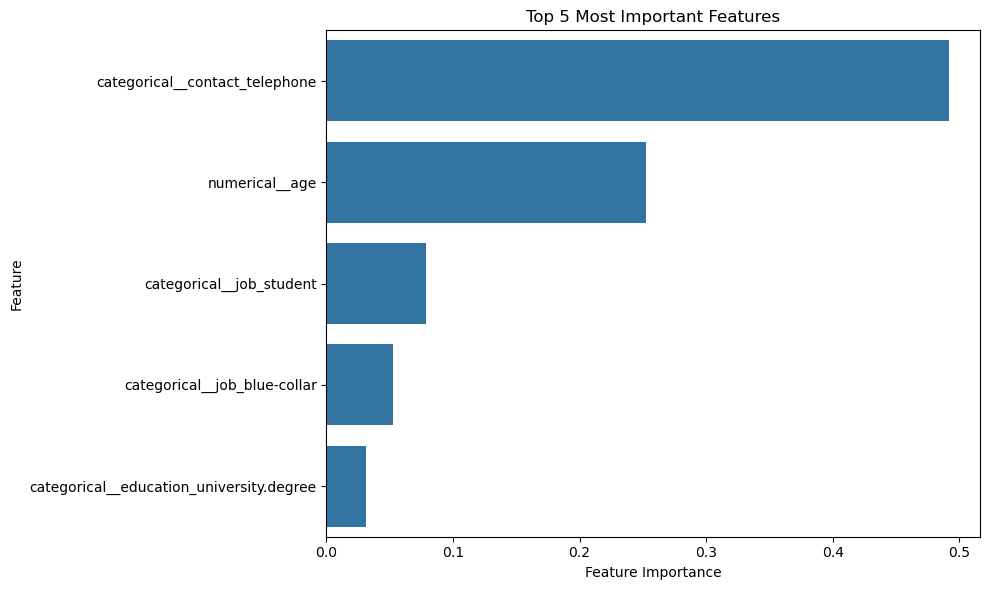

In [34]:
# Plot the most important features
tree_model = decision_tree.named_steps['model']
feature_names = decision_tree.named_steps['preprocessor'].get_feature_names_out()

importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(5), x='Importance', y='Feature')
plt.title('Top 5 Most Important Features')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('images/feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

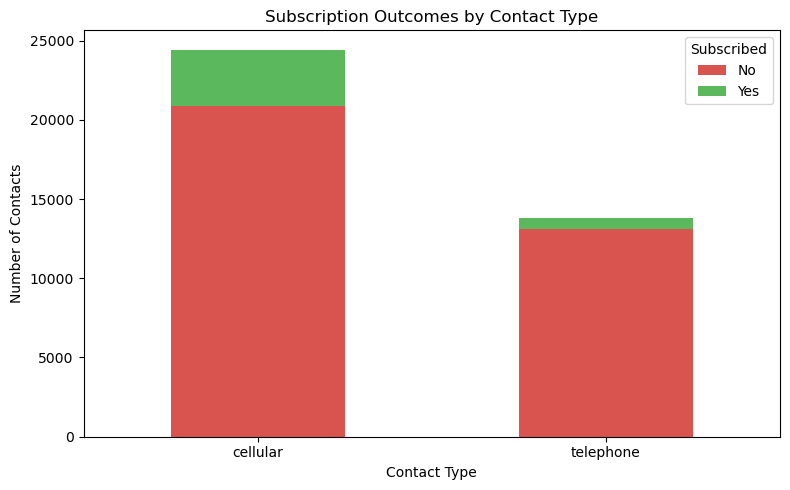

In [35]:
# Plot the subscription outcomes by contact type
contact_counts = df.groupby(['contact', 'y']).size().unstack()

contact_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=['#d9534f', '#5cb85c'],
    width=0.5
)
plt.title('Subscription Outcomes by Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Number of Contacts')
plt.xticks(rotation=0)
plt.legend(['No', 'Yes'], title='Subscribed')
plt.tight_layout()
plt.savefig('images/outcomes_contact_type.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# Create a table of the contact type success rates
contact_success = df.groupby('contact')['y'].mean().round(3) * 100
contact_success = contact_success.reset_index()
contact_success.columns = ['Contact Type', 'Success Rate (%)']
contact_success

,Contact Type,Success Rate (%)
0,cellular,14.5
1,telephone,5.2


The type of phone contact, cellular vs telephone (landline), ended up being the largest indicator of success.  Cellular customers were almost 3 times more likely to accept the offer as telephone users.

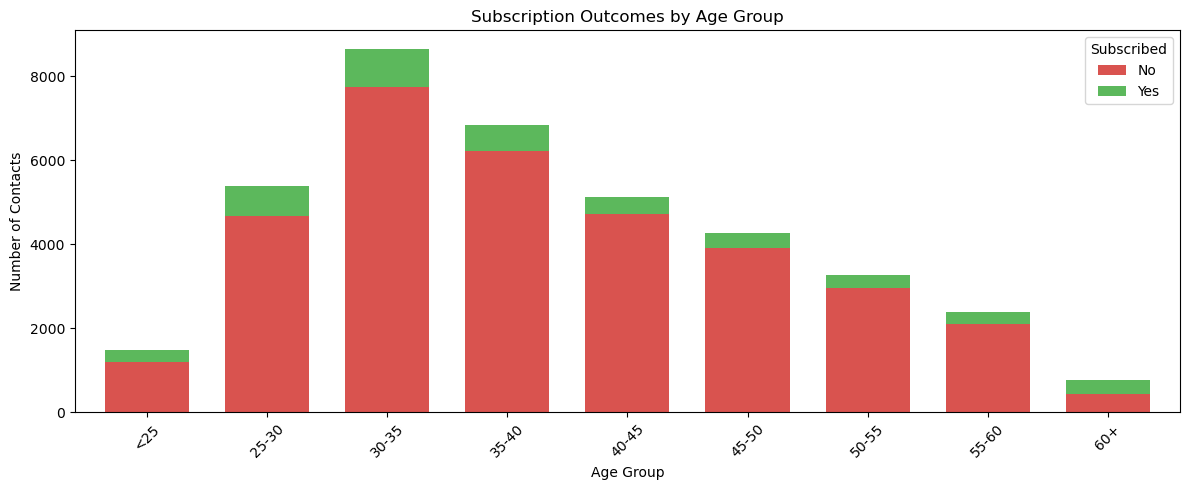

In [37]:
# Plot the subscription outcomes by age group
age_counts = df.groupby(['age', 'y']).size().unstack()

age_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 5),
    color=['#d9534f', '#5cb85c'],
    width=0.7
)
plt.title('Subscription Outcomes by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Contacts')
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
plt.legend(['No', 'Yes'], title='Subscribed')
plt.tight_layout()
plt.savefig('images/outcome_age_group.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Create a table of the age group success rates
age_success = df.groupby('age')['y'].mean().round(3) * 100
age_success = age_success.reset_index()
age_success.columns = ['Age Group', 'Success Rate (%)']
age_success['Age Group'] = labels
age_success

,Age Group,Success Rate (%)
0,<25,19.0
1,25-30,13.5
2,30-35,10.6
3,35-40,8.8
4,40-45,8.0
5,45-50,8.2
6,50-55,9.7
7,55-60,12.3
8,60+,44.9


Customers over 60 had a much higher success rate than other ages.  Younger ages also had a higher success rate than middle-aged customers.  Overall there is a parabolic U-shape relationship between age and acceptance rate.  Decision trees handle this data shape well without needing to introduce an age-squared feature.